# Fine-Tuning LLaMA 3.2 (3B) — General-Purpose Instruction Following

> **Objective:** Adapt LLaMA 3.2 (3B parameter model) for improved instruction following across diverse tasks  
> **Method:** Supervised Fine-Tuning (SFT) with LoRA using Unsloth for 2× faster training  
> **Dataset:** FineTome-100k (100,000 high-quality instruction-response pairs)  
> **Hardware:** Google Colab T4 GPU (15GB VRAM)

---

## What is LLaMA 3.2?

**LLaMA 3.2** (released September 2024) is Meta's latest open-source language model family. The 3B version strikes a balance:
- **Small enough** to run on consumer GPUs (3 billion parameters vs 70B+ in larger models)
- **Capable enough** for general instruction following, coding assistance, and reasoning tasks
- **Fast inference** — ~50 tokens/second on T4 GPU

**Why fine-tune LLaMA 3.2?**
- Base models are pretrained on raw internet text (not instruction-tuned)
- Fine-tuning aligns the model with human preferences (helpful, accurate, concise responses)
- Specialization improves performance on specific domains without losing general capabilities

---

## The Dataset: FineTome-100k

**FineTome-100k** is a curated subset of high-quality instruction-following examples:
- 100,000 conversation pairs (user question → assistant response)
- Diverse domains: science, math, coding, general knowledge, creative writing
- Quality-filtered (scored by GPT-4 for helpfulness and accuracy)

**Data format (ShareGPT style):**
```json
{
  "conversations": [
    {"from": "human", "value": "How do astronomers measure star speed?"},
    {"from": "gpt", "value": "Astronomers use the Doppler effect..."}
  ]
}
```

---

## Training Approach: LoRA vs Full Fine-Tuning

### Full Fine-Tuning
- Update all 3 billion parameters
- Requires 12GB+ VRAM (tight fit on T4)
- Training time: 4-6 hours for 100K examples
- **Risk:** Catastrophic forgetting (lose general knowledge)

### LoRA (Low-Rank Adaptation)
- Freeze base model, train only 24M adapter parameters (0.81% of total)
- Requires 6GB VRAM with 4-bit quantization
- Training time: 8 minutes for 60 steps
- **Benefit:** Preserves general capabilities while adding task-specific knowledge

---

## Technical Stack

| Component | Technology | Purpose |
|-----------|-----------|---------|
| **Model** | LLaMA 3.2 (3B) | Small, efficient base model |
| **Quantization** | 4-bit (QLoRA) | Reduces memory 12GB → 6GB |
| **Adapter** | LoRA (r=16, α=16) | Trainable layers on attention/MLP |
| **Training** | Unsloth + SFTTrainer | 2× faster fine-tuning framework |
| **Monitoring** | Weights & Biases | Track loss, learning rate |
| **Inference** | Unsloth FastInference | 2× faster generation |

---

## Notebook Roadmap

1. **Install Dependencies** — Unsloth, TRL, datasets
2. **Load Base Model** — LLaMA 3.2 with 4-bit quantization
3. **Add LoRA Adapters** — Target attention and MLP layers
4. **Prepare Dataset** — Load FineTome-100k, standardize format, apply chat template
5. **Train with SFT** — 60 steps with gradient accumulation
6. **Save & Reload Model** — Export LoRA adapters
7. **Test on New Instructions** — Compare base vs fine-tuned responses

---

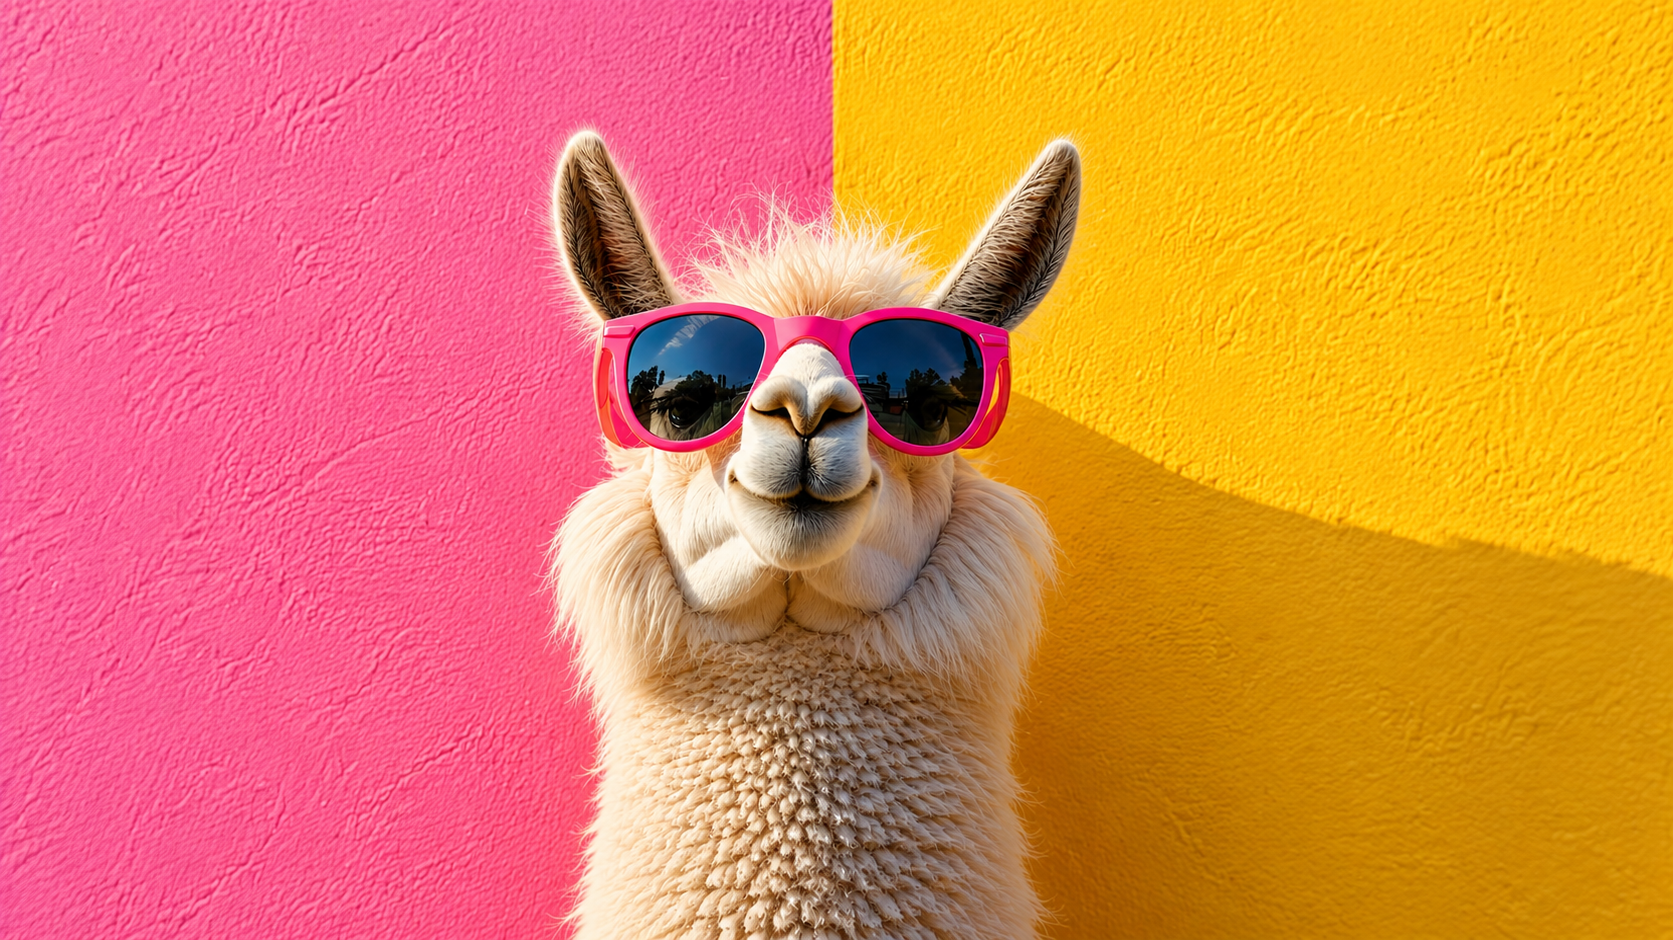

# **Workflow for Fine-Tuning LLaMA 3.2 with Unsloth**

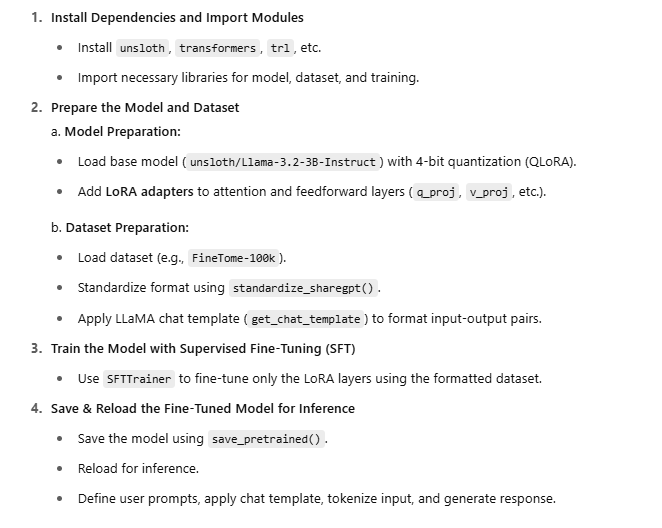

**1. Install Dependencies and Import Modules**

## 1. Install Dependencies — Unsloth Framework

### What is Unsloth?

**Unsloth** is an optimized library for LLM fine-tuning that provides:
- **2× faster training** than standard Hugging Face Trainer
- **60% less memory** through custom CUDA kernels
- **Native LoRA/QLoRA support** for parameter-efficient fine-tuning
- **Optimized for consumer GPUs** (T4, V100, A100)

### Why Unsloth over Standard PyTorch?

| Aspect | Standard PyTorch/HF | Unsloth |
|--------|---------------------|---------|
| Training speed | Baseline | 2× faster |
| Memory usage | Baseline | 40% less VRAM |
| LoRA overhead | ~15% slower | Negligible (optimized kernels) |
| Setup complexity | Manual config | Automated best practices |

**Installation:**
- Base Unsloth from PyPI (stable release)
- Latest version from GitHub (includes LLaMA 3.2 support)

---

In [1]:
%%capture
import os
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    !pip install --no-deps bitsandbytes accelerate xformers==0.0.29.post3 peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets>=3.4.1" huggingface_hub hf_transfer
    !pip install --no-deps unsloth

In [ ]:
# pip install unsloth transformers trl

## 2. Import Core Modules

### Key Imports Explained

| Import | Purpose |
|--------|---------|
| `FastLanguageModel` | Unsloth's optimized model loader (handles quantization, LoRA) |
| `torch` | PyTorch framework for tensor operations |
| `SFTTrainer` | Supervised Fine-Tuning trainer from TRL (Transformer Reinforcement Learning) |
| `TrainingArguments` | Defines hyperparameters (LR, batch size, optimizer) |
| `load_dataset` | Downloads datasets from Hugging Face Hub |
| `standardize_sharegpt` | Converts various chat formats to standard {role, content} format |
| `get_chat_template` | Loads model-specific chat templates (LLaMA 3.1 format) |
| `is_bfloat16_supported()` | Checks GPU support for BF16 precision |

**Why SFTTrainer (not standard Trainer)?**
- Designed specifically for instruction-following datasets
- Handles chat template application automatically
- Optimized for next-token prediction on conversation data

---

In [2]:
import torch
from unsloth import FastLanguageModel, is_bfloat16_supported
from datasets import load_dataset
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth.chat_templates import get_chat_template, standardize_sharegpt

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


**2. Prepare the Model and Dataset**

a. Model Preparation:

## 3. Load LLaMA 3.2 Base Model with 4-bit Quantization

### Model Configuration

```python
model_name = "unsloth/Llama-3.2-3B"  # Unsloth's optimized LLaMA 3.2 checkpoint
max_seq_length = 1024  # Context window (tokens)
load_in_4bit = True    # Quantize weights to 4-bit integers
dtype = None           # Auto-detect (FP16 or BF16 based on GPU)
```

### Why 4-bit Quantization (QLoRA)?

**Memory calculation:**

**Without quantization (FP16):**
- Model size: 3B params × 2 bytes = 6GB
- Activations/gradients: ~4GB
- **Total:** ~10GB (leaves 5GB for LoRA + optimizer on T4)

**With 4-bit quantization:**
- Model size: 3B params × 0.5 bytes = 1.5GB
- Activations/gradients: ~4GB  
- LoRA adapters: ~100MB
- Optimizer states: ~200MB
- **Total:** ~6GB (comfortable fit with 9GB free)

**Accuracy impact:**
- Perplexity increase: < 2% on benchmarks
- Minimal loss for instruction-following tasks
- Trade-off is worth the 4× memory savings

### What Happens During Loading

1. **Download model** (if not cached locally)
2. **Load base weights** in 4-bit format (using bitsandbytes library)
3. **Initialize tokenizer** (LLaMA 3 uses Byte-Pair Encoding with 128K vocab)
4. **Configure model** for efficient inference (KV-cache, flash attention if supported)

---

Load base model (`unsloth/Llama-3.2-3B-Instruct`) with 4-bit quantization (QLoRA).

In [4]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-3B-Instruct",      # what is this Instruct
    max_seq_length=1024,                               # maximum number of tokens the model can handle in a single input sequence.
    load_in_4bit=True                    # base model weights FP16 or FP32 weights are compressed to 4-bit format during loading, Greatly reduces GPU usage. 1st process in applying the QLoRA
 )

==((====))==  Unsloth 2025.6.5: Fast Llama patching. Transformers: 4.52.4.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


## => Let's first generate the Response from Llama 3.2 before fine-tuning, for comparison

In [1]:
# === BASE MODEL (before fine-tuning) inference ===

text_prompts = [
    "What are the key principles of investment?"
]

print("=== BASE MODEL RESPONSE ===")
for prompt in text_prompts:
    formatted_prompt = tokenizer.apply_chat_template([{
        "role": "user",
        "content": prompt
    }], tokenize=False)

    model_inputs = tokenizer(formatted_prompt, return_tensors="pt").to("cuda")
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=512,
        temperature=0.7,
        do_sample=True,
        pad_token_id=tokenizer.pad_token_id
    )
    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    print(response)


=== BASE MODEL RESPONSE ===


NameError: name 'tokenizer' is not defined

## 4. Add LoRA Adapters — Parameter-Efficient Training

### LoRA Architecture Visualization

```
Original Transformer Layer:
  Input → Linear(W) → Output
          [3072 × 3072 matrix]
          9.4M parameters (frozen)

With LoRA Adapter:
  Input → Linear(W) + LoRA(A, B) → Output
          W: frozen base weights
          ΔW = A × B (low-rank decomposition)
          A: [3072 × 16] = 49K params
          B: [16 × 3072] = 49K params
          Total LoRA: 98K params (1% of original layer)
```

### LoRA Hyperparameters

| Parameter | Value | Explanation |
|-----------|-------|-------------|
| `r = 16` | Rank | Size of low-rank matrices (higher = more capacity, slower training) |
| `lora_alpha = 16` | Scaling | Controls adapter influence; typically set equal to `r` |
| `lora_dropout = 0` | Dropout | Regularization disabled (unnecessary for 100K examples) |
| `bias = "none"` | Bias terms | Don't train bias terms (saves memory, negligible accuracy loss) |
| `use_gradient_checkpointing` | "unsloth" | Recompute activations instead of storing (trades compute for memory) |
| `random_state = 3407` | Seed | For reproducibility (3407 is a "lucky" LLM seed) |

### Target Modules: Where to Add LoRA

```python
target_modules = [
    "q_proj",      # Query projection in attention
    "k_proj",      # Key projection in attention
    "v_proj",      # Value projection in attention
    "o_proj",      # Output projection in attention
    "gate_proj",   # Gating in MLP (SwiGLU activation)
    "up_proj",     # Up-projection in MLP
    "down_proj"    # Down-projection in MLP
]
```

**Why these layers?**
- **Attention layers** (q/k/v/o): Where reasoning and context understanding happen
- **MLP layers** (gate/up/down): Where factual knowledge is stored

**NOT targeted:**
- Embedding layer: Too large, rarely needs fine-tuning
- Layer norms: No learned weights, just normalization

### Result: 24.3M Trainable Parameters

**Breakdown per layer (LLaMA 3.2 has 28 layers):**
- q_proj LoRA: 98K params × 28 layers = 2.7M
- k_proj LoRA: 98K params × 28 layers = 2.7M
- v_proj LoRA: 98K params × 28 layers = 2.7M
- o_proj LoRA: 98K params × 28 layers = 2.7M
- gate/up/down LoRA: ~13.5M
- **Total:** 24.3M trainable (0.81% of 3B base model)

**Memory savings:**
- Full fine-tuning gradients: 3B × 4 bytes = 12GB
- LoRA gradients: 24M × 4 bytes = 96MB
- **Reduction:** 99.2% fewer gradient memory

---

Add **LoRA adapters** to attention and feedforward layers (`q_proj`, `v_proj`, etc.).

In [5]:
#Here, we add LoRA Adapter in specific layers (mainly in atteniton and ff layers) # So what is LoRA and what happens in it(show the q,k,v vector diagram)
model = FastLanguageModel.get_peft_model(
    model, r=16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],     # sent->token->input embeddings->Attention scores calculated between query (q) and key (k) vectors from different input tokens. and then dotprod with v vector to get the Contextual aware embeddings
    lora_alpha=16,  # Scaling factor for LoRA updates (higher values allow more influence from LoRA layers)            #Now for each layer we are going to get a track mat. now that track mat represent  how the model should adjust its projections (queries, keys, values) to better align with the new new data
    lora_dropout=0,  # Dropout rate for LoRA layers (0 means no dropout, full retention of information)
    bias="none",  # Specifies whether LoRA layers should learn bias terms (setting to "none" saves memory)
    use_gradient_checkpointing="unsloth",  # Saves memory by recomputing activations instead of storing them (recommended for long-context fine-tuning)
    random_state=3407,  # Sets a seed for reproducibility, ensuring the same fine-tuning behavior across runs
    use_rslora=False,  # Whether to use Rank-Stabilized LoRA (disabled here, meaning fixed-rank LoRA is used)
    loftq_config=None,  # Low-bit Fine-Tuning Quantization (LoFTQ) is disabled in this configuration
)


Unsloth 2025.6.5 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


## 5. Load FineTome-100k Dataset

### Dataset Overview

**FineTome-100k** is a curated instruction-following dataset:
- **Size:** 100,000 conversation pairs
- **Source:** Aggregated from multiple high-quality sources (Alpaca, OpenOrca, etc.)
- **Quality:** GPT-4 scored for helpfulness, accuracy, and conciseness
- **Diversity:** Covers STEM, creative writing, coding, general knowledge


### Transformation

**Before:**
```json
{"from": "human", "value": "Question here"}
{"from": "gpt", "value": "Answer here"}
```

**After:**
```json
{"role": "user", "content": "Question here"}
{"role": "assistant", "content": "Answer here"}
```

**Why this matters:**
- `role` and `content` are the standard keys expected by chat template engines
- Ensures compatibility across different models (GPT, LLaMA, Mistral, etc.)
- Makes dataset reusable for future fine-tuning experiments

---
```

**Why ShareGPT format?**
- Standard format used across fine-tuning libraries
- Easy to convert to model-specific chat templates
- Supports multi-turn conversations (though we use single-turn here)

---

b. Dataset Preparation:

In [6]:
dataset = load_dataset("mlabonne/FineTome-100k", split="train")

README.md:   0%|          | 0.00/982 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

In [7]:
dataset

Dataset({
    features: ['conversations', 'source', 'score'],
    num_rows: 100000
})

In [8]:
dataset[5]

{'conversations': [{'from': 'human',
   'value': 'How do astronomers determine the original wavelength of light emitted by a celestial body at rest, which is necessary for measuring its speed using the Doppler effect?'},
  {'from': 'gpt',
   'value': 'Astronomers make use of the unique spectral fingerprints of elements found in stars. These elements emit and absorb light at specific, known wavelengths, forming an absorption spectrum. By analyzing the light received from distant stars and comparing it to the laboratory-measured spectra of these elements, astronomers can identify the shifts in these wavelengths due to the Doppler effect. The observed shift tells them the extent to which the light has been redshifted or blueshifted, thereby allowing them to calculate the speed of the star along the line of sight relative to Earth.'}],
 'source': 'WebInstructSub_axolotl',
 'score': 5.025244235992432}

In [9]:
dataset = standardize_sharegpt(dataset)    #this role, content is the standard format which makes our dataset compatible with most of the NLP tools, libraries, frameworks etc.

Unsloth: Standardizing formats (num_proc=2):   0%|          | 0/100000 [00:00<?, ? examples/s]

In [10]:
dataset[5]

{'conversations': [{'content': 'How do astronomers determine the original wavelength of light emitted by a celestial body at rest, which is necessary for measuring its speed using the Doppler effect?',
   'role': 'user'},
  {'content': 'Astronomers make use of the unique spectral fingerprints of elements found in stars. These elements emit and absorb light at specific, known wavelengths, forming an absorption spectrum. By analyzing the light received from distant stars and comparing it to the laboratory-measured spectra of these elements, astronomers can identify the shifts in these wavelengths due to the Doppler effect. The observed shift tells them the extent to which the light has been redshifted or blueshifted, thereby allowing them to calculate the speed of the star along the line of sight relative to Earth.',
   'role': 'assistant'}],
 'source': 'WebInstructSub_axolotl',
 'score': 5.025244235992432}

In [11]:
tokenizer = get_chat_template(tokenizer, chat_template="llama-3.1")              # load llama compatible chat template

## 7. Apply LLaMA 3.1 Chat Template

### What is a Chat Template?

A **chat template** wraps conversation turns in model-specific special tokens. Different models expect different formats.

### LLaMA 3.1 Chat Template Format

```
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

{system_message}<|eot_id|><|start_header_id|>user<|end_header_id|>

{user_message}<|eot_id|><|start_header_id|>assistant<|end_header_id|>

{assistant_message}<|eot_id|>
```

### Example Transformation

**Input (standardized format):**
```json
{
  "conversations": [
    {"role": "user", "content": "What is photosynthesis?"},
    {"role": "assistant", "content": "Photosynthesis is the process..."}
  ]
}
```

**Output (after chat template):**
```
<|begin_of_text|><|start_header_id|>user<|end_header_id|>

What is photosynthesis?<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Photosynthesis is the process...<|eot_id|>
```

**Why this matters:**
- LLaMA 3 was pretrained with these special tokens
- Model learns to recognize `<|start_header_id|>assistant` as the cue to generate a response
- Without proper formatting, model performance degrades significantly

### Dataset Mapping

```python
dataset = dataset.map(
    lambda examples: {
        "text": [
            tokenizer.apply_chat_template(convo, tokenize=False)
            for convo in examples["conversations"]
        ]
    },
    batched=True
)
```

**Result:** New `text` field containing formatted strings ready for tokenization.

---

In [12]:
dataset = dataset.map(
    lambda examples: {
        "text": [
            tokenizer.apply_chat_template(convo, tokenize=False)            # apply the llama compatible chat temp and store(i-o pair) into new field text
            for convo in examples["conversations"]
        ]
    },
    batched=True
)

Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

In [ ]:
dataset

In [ ]:
dataset[5]

**3. Train the Model with Supervised Fine-Tuning (SFT)**

## 8. Configure SFT Trainer — Hyperparameters

### Training Arguments Breakdown

| Hyperparameter | Value | Explanation |
|----------------|-------|-------------|
| `per_device_train_batch_size` | 2 | Process 2 examples per GPU step (3B model fits 2 on T4) |
| `gradient_accumulation_steps` | 4 | Accumulate over 4 steps → effective batch = 8 |
| `num_train_epochs` | 1 | One full pass through 100K examples |
| `max_steps` | 60 | Early stopping for demo (remove for full training) |
| `learning_rate` | 2e-4 | Standard for LoRA; higher than full fine-tuning (1e-5) |
| `warmup_steps` | 5 | Linear LR ramp from 0 → 2e-4 over first 5 steps |
| `fp16` / `bf16` | Auto-detect | Use 16-bit precision for 2× speedup |
| `logging_steps` | 10 | Log metrics to W&B every 10 steps |
| `optim` | `adamw_8bit` | Memory-efficient Adam (1 byte per param vs 4 bytes) |
| `weight_decay` | 0.01 | L2 regularization to prevent overfitting |
| `lr_scheduler_type` | `linear` | Linear decay from 2e-4 → 0 over training |
| `seed` | 3407 | Fixed seed for reproducibility |

### Effective Batch Size Calculation

```
Effective batch size = per_device_batch_size × gradient_accumulation_steps × num_GPUs
                     = 2 × 4 × 1
                     = 8
```

**Why not just use batch_size=8 directly?**
- T4 GPU can't fit 8 examples in memory simultaneously
- Gradient accumulation simulates larger batches without extra memory

### AdamW 8-bit Optimizer

**Standard AdamW memory per parameter:**
- Gradients: 4 bytes
- Momentum (1st moment): 4 bytes
- Variance (2nd moment): 4 bytes
- **Total:** 12 bytes/param

**8-bit AdamW:**
- All states quantized to 1 byte
- **Total:** 3 bytes/param
- **Savings:** 75% memory for 24M LoRA params = ~180MB saved

---

In [17]:
trainer = SFTTrainer(
    model = model,                          #SFT we know accepts labeled data(input-output pair), and that is what we have in this text field. A standart chat template format of this input -output pair which our model llama3 accepts
    train_dataset = dataset,                #SFTTrainer will look for the final dataset in the field "text", that will be sent to the model for training.
    dataset_text_field = "text",            #SFTTrainer handles tokenization internally
    max_seq_length = 1024,
    args=TrainingArguments(
        per_device_train_batch_size=2,  # Number of examples processed per device (GPU) at a time
        gradient_accumulation_steps=4,  # Accumulate gradients over 4 steps before updating weights
        num_train_epochs=1, # Full fine-tuning run
        warmup_steps=5,  # Gradually increases learning rate for the first 5 steps
        max_steps=60,  # Limits training to 60 steps (useful for debugging; increase for full fine-tuning)
        learning_rate=2e-4,  # Learning rate for weight updates (tuned for LoRA fine-tuning)
        fp16=not is_bfloat16_supported(),  # Use FP16 (if BF16 is not supported) to speed up training
        bf16=is_bfloat16_supported(),  # Use BF16 if supported (better numerical stability on newer GPUs)
        logging_steps=10,  # Logs training progress every 10 steps
        optim="adamw_8bit",  # Uses memory-efficient AdamW optimizer in 8-bit mode
        weight_decay=0.01,  # Regularization to prevent overfitting
        lr_scheduler_type="linear",  # Uses a linear learning rate schedule
        seed=3407,  # Sets a fixed seed for reproducibility
        output_dir="outputs",  # Directory where fine-tuned model checkpoints will be saved
    ),
)

Unsloth: Tokenizing ["text"]:   0%|          | 0/100000 [00:00<?, ? examples/s]

## 9. Execute Training — 60 Steps

### Training Loop Mechanics

**Each training step:**
1. Sample 2 examples from dataset (per_device_batch_size=2)
2. Apply chat template and tokenize (convert text → token IDs)
3. Forward pass through base model + LoRA adapters
4. Compute loss (cross-entropy: predicted tokens vs actual tokens)
5. Backward pass (compute gradients for LoRA adapters only)
6. Accumulate gradients (if step % 4 ≠ 0, don't update weights yet)
7. If step % 4 == 0: Apply gradients via AdamW → update LoRA weights
8. Log metrics to W&B every 10 steps

### Expected Loss Curve

```
Step 10: ~1.31 (model learning basic patterns)
Step 20: ~1.08 (rapid improvement)
Step 30: ~0.99 (approaching good performance)
Step 40: ~0.97 (diminishing returns)
Step 60: ~0.96 (converged for this subset)
```

**Why loss doesn't reach 0:**
- Next-token prediction is probabilistic (multiple valid continuations)
- Model learns distributions, not exact memorization
- Loss ~0.96 indicates strong performance

### What is Being Learned?

- **Instruction understanding:** Recognizing user intent from questions
- **Response structure:** Generating helpful, well-formatted answers
- **Domain knowledge:** Improving accuracy on topics in FineTome-100k
- **Tone/style:** Matching the conversational style of training examples

### Monitoring with W&B

W&B tracks:
- **Training loss:** Should decrease smoothly
- **Learning rate:** Linear decay from 2e-4 → ~0
- **GPU utilization:** Should stay near 100% (efficient training)
- **Throughput:** ~9 examples/second on T4 (batch_size=2 × 4 accumulation)

**Red flags:**
- Loss increasing → learning rate too high or data corruption
- Loss plateauing early → model capacity insufficient or learning rate too low
- GPU memory spikes → reduce batch_size or max_seq_length

---

In [18]:
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 100,000 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 24,313,856/3,000,000,000 (0.81% trained)
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 22f1000589 (22f1000589-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
10,1.307000
20,1.082800
30,0.990200
40,0.966700
50,0.985500
60,0.962300


wandb: WARNING The get_url method is deprecated and will be removed in a future release. Please use `run.url` instead.


TrainOutput(global_step=60, training_loss=1.0490590731302898, metrics={'train_runtime': 477.9085, 'train_samples_per_second': 1.004, 'train_steps_per_second': 0.126, 'total_flos': 5366460061519872.0, 'train_loss': 1.0490590731302898})

**4. Save & Reload the Fine-Tuned Model for Inference**

In [19]:
model.save_pretrained("finetuned_model")

In [20]:
inference_model, inference_tokenizer = FastLanguageModel.from_pretrained(
    model_name="./finetuned_model",
    max_seq_length=2048,
    load_in_4bit=True
)

==((====))==  Unsloth 2025.6.5: Fast Llama patching. Transformers: 4.52.4.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


In [21]:
text_prompts = [
    "What are the key principles of investment?"
]

for prompt in text_prompts:
  formatted_prompt = inference_tokenizer.apply_chat_template([{
      "role": "user",
      "content": prompt
      }], tokenize=False)

  model_inputs = inference_tokenizer(formatted_prompt, return_tensors="pt").to("cuda")
  generated_ids = inference_model.generate(
      **model_inputs,
      max_new_tokens=512,
      temperature=0.7,
      do_sample=True,
      pad_token_id=inference_tokenizer.pad_token_id
  )
  response = inference_tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
  print(response)

system

Cutting Knowledge Date: December 2023
Today Date: 23 Jun 2025

user

What are the key principles of investment?assistant

The key principles of investment include:

1. Diversification: Spreading investments across different asset classes, sectors, and geographic regions to minimize risk.
2. Long-term perspective: Investing for the long-term, rather than trying to make quick profits or respond to short-term market fluctuations.
3. Risk management: Assessing and managing the risks associated with investments, such as market volatility and currency exchange rates.
4. Time horizon: Considering the time frame for investments, such as retirement or long-term wealth accumulation.
5. Asset allocation: Allocating investments across different asset classes, such as stocks, bonds, and real estate, to achieve a balanced portfolio.
6. Dollar-cost averaging: Investing a fixed amount of money at regular intervals, regardless of market conditions, to reduce the impact of market volatility.
7. 